In [2]:
from tqdm import tqdm
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 构造数据

## 环境变量

$$
\begin{align*}

e &:\ [w, r, n, v, m^{\text{<ack>}}]                                                \\
e &:\ \text{environmental variable}                                                 \\
w &:\ \text{weather condition}  \in \{ 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 \}             \\
r &:\ \text{road condition}  \in \{ 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 \}                \\
n &:\ \text{surrounding vehicles condition} \in \{ 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 \} \\
v &:\ \text{vehicle speed} \in \{ 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 \}                  \\

\end{align*}
$$


$$
\text{hazard level } h = \begin{cases}
    1 & \text{lowest accident risk}   \\
    10 & \text{highest accident risk} \\
\end{cases}
$$


$$
\text{ACK message } m^{\text{<ack>}} = \begin{cases}
    1 & \text{ACK received (no retransmission)}           \\
    2 & \text{ACK not received (retransmission required)} \\
\end{cases}
$$

### 正态分布
$$
\begin{align*}

\mathcal{X} \sim \mathcal{N}(\mu, \sigma^{2})

\end{align*}
$$

#### 密度函数
$$
\begin{align*}

\mathcal{f(x)} = \frac{1}{\sigma \sqrt{2 \pi}} \exp{
    \left(
        -\frac{(x - \mu)^{2}}{2 \sigma^{2}}
    \right)
}

\end{align*}
$$

$$
\begin{align*}

w = \mathrm{Clamp}_{[1, 10]} \left(
        \mathrm{Round} \left(
            \mathcal{N}(5.5, 2^2)
        \right)
    \right)

\end{align*}
$$

In [3]:
def generate_weather_condition(batch_size, device = "cpu"):
    w = torch.normal(5.5, 2.0, size = (batch_size, ), device = device)
    return torch.clamp(w.round(), 1, 10)

$$
\begin{align*}

r_{\mathrm{prior}} &= \mathcal{N}(5.5, 1^{2})                     \\

r &= \mathrm{Clamp}_{[1, 10]} \left(
    \mathrm{Round} \left(
        r_{\mathrm{prior}} + 0.5(w - 5.5) + \mathcal{N}(0, 1^{2})
    \right)
\right)                                                           \\

\end{align*}
$$

In [4]:
def generate_road_condition(w):
    prior = torch.normal(5.5, 1.0, size = (w.shape[0], ), device = w.device)
    noise = torch.normal(0, 1.0, size = (w.shape[0], ), device = w.device)
    other = 0.5 * (w - 5.5)
    r = prior + other + noise
    return torch.clamp(r.round(), 1, 10)

$$
\begin{align*}

d_{\mathrm{prior}} &= r_{min} + r_{\max} - r = 11 - r \\

d &= \mathrm{Clamp}_{[1, 10]} \left( d_{\mathrm{prior}} + \mathcal{N}(0, 1^{2}) \right)

\end{align*}
$$


In [5]:
def generate_traffic_density(r):
    prior = 11.0 - r
    noise = torch.normal(0, 1.0, size = (r.shape[0], ), device = r.device)
    d = prior + noise
    return torch.clamp(d, 1, 10)

### 高斯函数
$$
\begin{align*}

\mathcal{f(x)} = A \exp{
    \left(
        -\frac{(x - \mu)^{2}}{2\sigma^{2}}
    \right)
}

\end{align*}
$$

$$
\begin{align*}

n_{\mathrm{prior}} &= A \exp{
    \left(
        -\frac{(d - \mu)^{2}}{2 \sigma^{2}}
    \right)
} \\

 &= 10 \cdot \exp \left( 
    -\frac{(d - 5.5)^{2}}{2 \cdot 2^{2}}
\right)

\end{align*}
$$

$$
n = \mathrm{Clamp}_{[1, 10]} \left(
    \mathrm{Round} \left(
        n_{\mathrm{prior}} + \mathcal{N}(0, 1^{2})
    \right)
\right)
$$

In [6]:
def generate_surrounding_vehicles_condition(d):
    prior = 10.0 * torch.exp(-((d - 5.5) ** 2) / (2 * (2.0 ** 2)))
    noise = torch.normal(0, 1.0, size = (d.shape[0], ), device = d.device)
    n = prior + noise
    return torch.clamp(n.round(), 1, 10)

$$
\begin{align*}

V &\sim 
\begin{cases}
\mathcal{N}(0, 1) & &u < 0.70 \\
\mathcal{N}(0, 3) & 0.70 \le &u < 0.95 \\
\mathcal{N}(0, 6) & &u \ge 0.95
\end{cases}

\quad u \sim U(0,1)

\quad v_{\text{prior}} = |V| \\

v_{\mathrm{d}} &= A \exp{
    \left(
        -\frac{(d - \mu)^{2}}{2 \sigma^{2}}
    \right)
} = 2 \cdot \exp \left( 
    -\frac{(d - 5.5)^{2}}{2 \cdot 2^{2}}
\right) \\

v &= \mathrm{Clamp}_{[1, 10]} \left(
    \mathrm{Round} \left(
        v_{\mathrm{prior}} + v_{\mathrm{d}} + \mathcal{N}(0, 1^{2})
    \right)
\right)

\end{align*} 
$$

In [7]:
def generate_prior_vehicle_speed(batch_size, device = "cpu"):
    u = torch.rand(batch_size, device = device)
    mask1 = u < 0.70
    mask2 = (u >= 0.70) & (u < 0.95)
    mask3 = u >= 0.95

    v = torch.empty(batch_size, device = device)
    v[mask1] = torch.normal(0, 1.0, size = (mask1.sum(), ), device = device)
    v[mask2] = torch.normal(0, 3.0, size = (mask2.sum(), ), device = device)
    v[mask3] = torch.normal(0, 6.0, size = (mask3.sum(), ), device = device)

    return v.abs()

In [8]:
def generate_vehicle_speed(d):
    prior = generate_prior_vehicle_speed(d.shape[0], device = d.device)
    noise = torch.normal(0, 1.0, size = (d.shape[0], ), device = d.device)
    other = 2.0 * torch.exp(-((d - 5.5) ** 2) / (2 * (2.0 ** 2))) # traffic density -> vehicle_speed
    
    v = prior + other + noise
    return torch.clamp(v.round(), 1, 10)

### received signal to interference plus noise ratio(SINR)
$$
\begin{align*}

\eta = \frac{P_{R}}{\sigma_{I} + \sigma_{N}}

\end{align*}
$$

$$
\begin{align*}

P_{R} &= \alpha(w_{\max} + w_{\min} - w) + \beta(d_{\max} + d_{\min} - d) + \mathcal{N}(0, 1^{2}) \\

&= \alpha(11 - w) + \beta(11 - d) + \mathcal{N}(0, 1^{2}) \\

&= 1.2(11 - w) + 0.8(11 - d) + \mathcal{N}(0, 1^{2}) \\
\\
\sigma_{I} &= \beta_{1}d + \mathcal{N}(0, 1) = 0.4d + \mathcal{N}(0, 1) \\
\sigma_{N} &= \sigma_{0} + \mathcal{N}(0, 0.1) = 1 + \mathcal{N}(0, 0.1) \\

\end{align*}
$$

In [9]:
def generate_SINR(w, d):
    P_R = (1.2 * (11 - w) + 0.8 * (11 - d) + torch.normal(0, 1.0, size = (w.shape[0], ), device = w.device)).relu()
    sigma_I = (0.4 * d + torch.normal(0, 1.0, size = (w.shape[0], ), device = w.device)).relu()
    sigma_N = (1.0 + torch.normal(0, 0.1, size = (w.shape[0], ), device = w.device)).relu()
    SINR = P_R / (sigma_I + sigma_N + 1e-6)
    return SINR

In [10]:
def generate_channel_condition(SINR):
    SINR_db = 10 * torch.log10(SINR + 1e-6)
    c = torch.floor((SINR_db + 5) / 2.5) + 1
    return torch.clamp(c, 1, 10).long()

$$
\begin{align*}

l_{action} = l_{\text{optimal}} = 
\begin{cases}
1 & c \in \{ 1, 2 \} \\
2 & c \in \{ 3, 4, 5 \} \\
3 & c \in \{ 6, 7, 8 \} \\
4 & c \in \{ 9, 10 \}
\end{cases} 

\end{align*}
$$

In [11]:
def generate_communication_rate(c):
    l = torch.ones_like(c)
    l = torch.where((3 <= c) & (c <= 5), torch.tensor(2, device = c.device), l)
    l = torch.where((6 <= c) & (c <= 8), torch.tensor(3, device = c.device), l)
    l = torch.where(c >= 9, torch.tensor(4, device = c.device), l)
    return l

$$
\begin{align*}

m^{\text{<ack>}} = 
\begin{cases}
1 & l_{\text{action}} \leq l_{\text{optimal}} \\
2 & l_{\text{action}} > l_{\text{optimal}}
\end{cases}

\end{align*}
$$

In [12]:
def generate_ack_message(l_action, l_optimal):
    success = (l_action <= l_optimal).long()
    twos = torch.full_like(success, 2)
    ones = torch.ones_like(success)
    return torch.where(success == 1, ones, twos)

In [13]:
def generate_environmental_variable_and_channel_condition(batch_size, device = "cpu"):
    w = generate_weather_condition(batch_size, device)
    r = generate_road_condition(w)
    d = generate_traffic_density(r)
    n = generate_surrounding_vehicles_condition(d)
    v = generate_vehicle_speed(d)

    SINR1 = generate_SINR(w, d)
    SINR2 = generate_SINR(w, d)

    c1 = generate_channel_condition(SINR1)
    c2 = generate_channel_condition(SINR2)

    l_action = generate_communication_rate(c1)
    l_optimal = generate_communication_rate(c2)

    m_ack = generate_ack_message(l_action, l_optimal)

    return torch.stack([w, r, n, v, m_ack], dim = 1), c1

## 状态

$$
\begin{align*}

s &:\ [e, c, q, m] \\
s &:\ \text{state} \\
e &:\ \text{environmental variable} \\
c &:\ \text{channel condition}  \in \{ 1, 2, 3, 4, 5, 6, 7, 8, 9, 10 \} \\
q &:\ \text{DENM message queue state. status of the DENM message queue, indicates the age of the oldest DENM message in the current queue.} \in \{ 1, 2, 3, 4 \} \\
m &:\ \text{message} \in \{ 0, 1, 2, 3 \} \\

\end{align*}
$$

$$
\begin{align*}

p_{u} &= \tau_{w}^{(w)}p_{w}^{(w)} + \tau_{r}^{(r)}p_{r}^{(r)} + \tau_{n}^{(n)}p_{n}^{(n)} + \tau_{v}^{(v)}p_{v}^{(v)}

\end{align*}
$$

In [14]:
def generate_unexpected_event_probability(e):
    w = e[:, 0]
    r = e[:, 1]
    n = e[:, 2]
    v = e[:, 3]

    w_norm = (w - 1) / 9.0
    r_norm = (r - 1) / 9.0
    n_norm = (n - 1) / 9.0
    v_norm = (v - 1) / 9.0

    tau_w = 0.25
    tau_r = 0.25
    tau_n = 0.30
    tau_v = 0.20

    p_u = tau_w*w_norm + tau_r*r_norm + tau_n*n_norm + tau_v*v_norm
    return p_u

$$
\begin{aligned}

p_{\text{shifted}} &= \begin{cases}
0              &       p_{u} + \delta  <  0 \\
p_{u} + \delta & 0 \le p_{u} + \delta \le 1 \\
1              & 1  <  p_{u} + \delta
\end{cases} \\

q' &= 1 + \lfloor 
    (q_{\max} - 1)(p_{\text{shifted}})^{\alpha} 
\rfloor \\

q &= \begin{cases}
1        &       q'  <  1        \\
q'       & 1 \le q' \le q_{\max} \\
q_{\max} &       q'  >  q_{\max}
\end{cases}

\end{aligned}
$$

In [15]:
def generate_denm_message_queue_state(p_u, q_max = 4, alpha = 3.0, delta = 0.05):
    p_shifted = torch.clamp(p_u + delta, 0, 1)
    q = 1 + torch.floor((q_max - 1) * torch.pow(p_shifted, alpha))
    return q.clamp(1, q_max).long()

$$
\begin{align*}

m = 
\begin{cases}
0 & \text{No message} \\
1 & \text{CAM message} \\
2 & \text{DENM message} \\
3 & \text{CAM and DENM message entering the message queue at this time}
\end{cases}

\end{align*}
$$

In [16]:
def generate_message_type(p_u, cam_freq = 0.7):
    p_m0 = (1.0 - cam_freq) * (1.0 - p_u)
    p_m1 = cam_freq * (1.0 - p_u)
    p_m2 = (1.0 - cam_freq) * p_u
    p_m3 = cam_freq * p_u
    
    probs = torch.stack([p_m0, p_m1, p_m2, p_m3], dim = -1)
    m = torch.multinomial(probs, num_samples = 1)
    return m.squeeze(1)

In [17]:
def generate_state_and_unexpected_event_probability(batch_size, device = "cpu"):
    e, c = generate_environmental_variable_and_channel_condition(batch_size, device) # e: [B,5], c: [B]
    p_u = generate_unexpected_event_probability(e) # [B]
    q = generate_denm_message_queue_state(p_u)  # [B]
    m = generate_message_type(p_u)  # [B]

    c = c.unsqueeze(1)  # [B, 1]
    q = q.unsqueeze(1)  # [B, 1]
    m = m.unsqueeze(1)  # [B, 1]

    state = torch.cat([e, c, q, m], dim = 1) # [B,8]

    return state, p_u

# ADMM-Net

$$
\begin{align*}

\textbf{X}&\textbf{-update (Low-rank Module)} \\

\mathcal{D}_{\tau}(X) &= \mathrm{Conv2D} \left( \mathrm{ReLU_{\tau} \left( \mathrm{Conv2D}(X) \right) } \right) \\

\mathrm{X}^{(k + 1)} &= \mathrm{Conv2D} \left( \mathrm{ReLU} \left( \mathrm{Conv2D} \left( Z^{(k)} - U^{(k)} \right) - \frac{\rho}{2} \right) \right)

\end{align*}
$$

In [18]:
class UpdateBlockX(nn.Module):
    def __init__(self, conv1, conv2, init_tau = 0.1):
        super().__init__()
        self.conv1 = conv1
        self.conv2 = conv2
        self.tau = nn.Parameter(torch.tensor(init_tau, dtype = torch.float32))  # ρ/2

    # [B, 1, 1, F] -> [B, h, 1, F] -> [B, 1, 1, F]
    def forward(self, Z0_minus_U0):
        return self.conv2(F.relu(self.conv1(Z0_minus_U0) - self.tau))

$$
\begin{align*}

\textbf{Z}&\textbf{-update (Threshold Module)} \\
T &= X^{(k+1)} - U^{(k)} + Z^{(k)} \\
Z^{(k+1)} &= Soft_{\tau}(T) = sign(T) · \mathrm{ReLU} \left( |T| - \frac{\lambda}{\rho} \right) \\

\end{align*}
$$

In [19]:
class UpdateBlockZ(nn.Module):
    def __init__(self, init_tau = 0.1):
        super().__init__()
        self.tau = nn.Parameter(torch.tensor(init_tau, dtype = torch.float32))  # λ/ρ

    def forward(self, X1, Z0_minus_U0):
        T = X1 + Z0_minus_U0
        
        return torch.sign(T) * F.relu(torch.abs(T) - self.tau)

$$
\begin{align*}

\textbf{U-update}&\textbf{ (Multiplier Module)} \\
U^{(k+1)} &= U^{(k)} + X^{(k+1)} - Z^{(k+1)} \\

\end{align*}
$$


In [20]:
class UpdateBlockU(nn.Module):
    def forward(self, U0, X1, Z1):
        return U0 + X1 - Z1

In [21]:
class AdmmBlock(nn.Module):
    def __init__(self, conv1, conv2, init_tau_x = 0.1, init_tau_z = 0.1):
        super().__init__()
        self.x_updater = UpdateBlockX(conv1, conv2, init_tau = init_tau_x)
        self.z_updater = UpdateBlockZ(init_tau = init_tau_z)
        self.u_updater = UpdateBlockU()

    def forward(self, Z0, U0):
        Z0_minus_U0 = Z0 - U0
        X1 = self.x_updater(Z0_minus_U0)
        Z1 = self.z_updater(X1, Z0_minus_U0)
        U1 = self.u_updater(U0, X1, Z1)
        
        return X1, Z1, U1

In [22]:
class AdmmNet(nn.Module):
    def __init__(self,iter_count = 6, conv_channel_cnt = 8, init_tau_x = 0.1, init_tau_z = 0.1):
        super().__init__()
        self.iter_count = iter_count

        self.shared_conv1 = nn.Conv2d(
            in_channels = 1,
            out_channels = conv_channel_cnt,
            kernel_size = 3,
            padding = 1,
            bias = True
        )

        self.shared_conv2 = nn.Conv2d(
            in_channels = conv_channel_cnt,
            out_channels = 1,
            kernel_size = 3,
            padding = 1,
            bias = True
        )

        blocks = []
        for _ in range(iter_count):
            blocks.append(
                AdmmBlock(
                    conv1 = self.shared_conv1,
                    conv2 = self.shared_conv2,
                    init_tau_x = init_tau_x,
                    init_tau_z = init_tau_z
                )
            )

        self.blocks = nn.ModuleList(blocks)

    def forward(self, Z0, U0):
        Z, U = Z0, U0
        X = None
        for block in self.blocks:
            X, Z, U = block(Z, U)

        return X, Z, U

In [82]:
def save_model(model, model_name, path):
    torch.save(model.state_dict(), path)
    print(f"已保存 {model_name} 模型至: {path}")

def load_admm_net(config, path):
    iter_count = config["iter_count"]
    init_tau_x = config["init_tau_x"]
    init_tau_z = config["init_tau_z"]
    conv_channel_cnt = config["conv_channel_cnt"]
    
    model = AdmmNet(iter_count, conv_channel_cnt, init_tau_x, init_tau_z)
    state_dict = torch.load(path, map_location = torch.device("cpu"))
    model.load_state_dict(state_dict)
    
    print(f"已加载 ADMM-Net 模型自: {path}")
    
    return model

In [ ]:
class ConfigurableMLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        
        modules = []
        for i in range(len(layers) - 1):
            in_dim = layers[i]
            out_dim = layers[i + 1]
            modules.append(nn.Linear(in_dim, out_dim))

            # 最后一层不加激活
            if i < len(layers) - 2:
                modules.append(nn.ReLU())

        self.network = nn.Sequential(*modules)

    def forward(self, Z0, U0 = None):
        B, _, _, F = Z0.shape # B, 1, 1, F

        x = Z0.view(B, F) # [B, F]

        x_pred = self.network(x)   # [B, F]

        X_pred = x_pred.view(B, 1, 1, -1) # [B,1,1,F]

        Z_pred = X_pred
        U_pred = torch.zeros_like(X_pred)

        return X_pred, Z_pred, U_pred


## 损失函数

$$
\begin{align*}

L_{\delta}(x) = \begin{cases}
    
    \frac{1}{2} x^{2}               & |x| \le \delta \\

    \delta(|x| - \frac{1}{2}\delta) & |x|  >  \delta \\

\end{cases}

\quad \delta = 1.0

\end{align*}
$$

In [24]:
def calc_huber_loss(tgt, pred, mask, delta = 1.0):
    x = pred[mask] - tgt[mask]
    x_abs_val = x.abs()
    quadratic = 0.5 * x.pow(2)
    linear = delta * (x_abs_val - 0.5 * delta)
    loss = torch.where(x_abs_val <= delta, quadratic, linear)
    return loss.mean(), x.numel()

$$
\begin{align*}
S &\in \mathbb{R}^{m \times n} \\
n &: 特征数量                   \\
m &: 样本数量                   \\
\end{align*}
$$

特征空间
$$
\begin{align*}

    A    &= S^{T}S \in \mathbb{R}^{n \times n}        \\

a_{i, j} &= \sum_{k = 1}^{m}(S_{k, i} \cdot S_{k, j}) \\

\end{align*}
$$

$$
\begin{align*}

\Lambda = 

\left[ \begin{array}{cccc}
\lambda_{1} &        0    & \cdots &        0    \\
       0    & \lambda_{2} & \cdots &        0    \\
    \vdots  &     \vdots  &        &     \vdots  \\
       0    &        0    & \cdots & \lambda_{n} \\
\end{array} \right]

=

&\left[ \begin{array}{cccc}
\sigma_{1}^{2} &         0      & \cdots &         0      \\
       0       & \sigma_{2}^{2} & \cdots &         0      \\
    \vdots     &      \vdots    &        &      \vdots    \\
       0       &         0      & \cdots & \sigma_{n}^{2} \\
\end{array} \right]

= \Sigma^{2} \\

&\sigma_{1} \ge \sigma_{2} \ge ... \ge \sigma_{n} \ge 0 \\

\end{align*}
$$

特征向量

$$
\begin{align*}

AV &= V \Lambda \\

\left[ \begin{array}{cccc}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots &        & \vdots \\
a_{n1} & a_{n2} & \cdots & a_{nn} \\
\end{array} \right]

\left[ \begin{array}{cccc}
v_{11} & v_{12} & \cdots & v_{1n} \\
v_{21} & v_{22} & \cdots & v_{2n} \\
\vdots & \vdots &        & \vdots \\
v_{n1} & v_{n2} & \cdots & v_{nn} \\
\end{array} \right]

&=

\left[ \begin{array}{cccc}
v_{11} & v_{12} & \cdots & v_{1n} \\
v_{21} & v_{22} & \cdots & v_{2n} \\
\vdots & \vdots &        & \vdots \\
v_{n1} & v_{n2} & \cdots & v_{nn} \\
\end{array} \right]

\left[ \begin{array}{cccc}
\lambda_{1} &        0    & \cdots &        0    \\
       0    & \lambda_{2} & \cdots &        0    \\
    \vdots  &     \vdots  &        &     \vdots  \\
       0    &        0    & \cdots & \lambda_{n} \\
\end{array} \right] \\

\left[ \begin{array}{cccc}
\sum_{i = 1}^{n}(a_{1i}v_{i1})   &   \sum_{i = 1}^{n}(a_{1i}v_{i2})   &   \cdots   &   \sum_{i = 1}^{n}(a_{1i}v_{in}) \\
\sum_{i = 1}^{n}(a_{2i}v_{i1})   &   \sum_{i = 1}^{n}(a_{2i}v_{i2})   &   \cdots   &   \sum_{i = 1}^{n}(a_{2i}v_{in}) \\
            \vdots               &               \vdots               &            &               \vdots             \\
\sum_{i = 1}^{n}(a_{ni}v_{i1})   &   \sum_{i = 1}^{n}(a_{ni}v_{i2})   &   \cdots   &   \sum_{i = 1}^{n}(a_{ni}v_{in}) \\
\end{array} \right]

&=

\left[ \begin{array}{cccc}
\lambda_{1}v_{11} & \lambda_{2}v_{12} & \cdots & \lambda_{n}v_{1n} \\
\lambda_{1}v_{21} & \lambda_{2}v_{22} & \cdots & \lambda_{n}v_{2n} \\
       \vdots     &        \vdots     &        &        \vdots     \\
\lambda_{1}v_{n1} & \lambda_{2}v_{n2} & \cdots & \lambda_{n}v_{nn} \\
\end{array} \right]

\end{align*}
$$

$$
\begin{align*}

\left[ \begin{array}{cccc}
a_{i1} & a_{i2} & \cdots & a_{in}
\end{array} \right]

\cdot

\left[ \begin{array}{c}
v_{1j} \\
v_{2j} \\
\vdots \\
v_{nj} \\
\end{array} \right]

&=

\lambda_{j}v_{ij} \\

\sum_{k = 1}^{n}(a_{ik} \times v_{kj}) &= \lambda_{j} \times v_{ij} \\

\lambda_{j} &= \sum_{k = 1}^{n}(a_{ik} \times \frac{v_{kj}}{v_{ij}}) \\

\lambda_{i} &= \sum_{k = 1}^{n}(a_{ik} \times \frac{v_{ki}}{v_{ii}}) \quad v_{ii} = 1

\end{align*}
$$

$$
\begin{align*}

  Z       &\in \mathbb{R}^{m \times n}  \\

  Z       &= U\sum{}V^{T}               \\

\|Z\|_{*} &= \sum_{i = 1}^{r}\sigma_{i} \\

\end{align*}
$$

In [25]:
def calc_nuclear_norm(z):
    Z = z.view(z.size(0), -1)
    s = torch.linalg.svdvals(Z)
    return s.sum() / Z.size(0)

$$
\begin{align*}

\min_{X, Z} &\left(
    
    \sum_{i,j \in \Theta}L_{\delta}(X_{i, j} - Y_{i, j}) + \lambda\| Z \|_{*}

\right)                      \\

&\text{s.t.} \quad X - Z = U \\

\end{align*}
$$

In [26]:
def calc_loss(tgt, pred, mask, z = None, delta = 1.0, lambda_coef = 0.0):
    huber_loss, cnt = calc_huber_loss(tgt, pred, mask, delta)

    loss = huber_loss
    if z is not None and lambda_coef > 0:
        loss = loss + lambda_coef * calc_nuclear_norm(z)

    return loss, cnt

# 训练ADMM-Net

In [91]:
def setup_seed(seed = 0):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [27]:
def generate_mask(tensor, missing_rate):
    return (torch.rand_like(tensor) > missing_rate).float()

In [147]:
def train_admm_net(device, model, optimizer,
    start_epoch,
    end_epoch,
    save_model_per_n_epoch,
    model_name,
    model_path,
    batch_size= 1024,
    lambda_coef = 0.001,
    delta = 1.0
):
    model.train()

    for epoch in range(start_epoch, end_epoch + 1):
        state, _ = generate_state_and_unexpected_event_probability(batch_size, device = device)
        tgt = state  # [B, F]
        B, F = tgt.shape
        
        missing_rate = torch.empty(B, F, device=device).uniform_(0.1, 0.9)  # [B, F]
        mask = generate_mask(tgt, missing_rate).to(device)

        Z0 = (tgt.unsqueeze(1).unsqueeze(2)) * (mask.unsqueeze(1).unsqueeze(2)) # [B, 1, 1, F] * [B, 1, 1, F]
        U0 = torch.zeros_like(Z0)

        X_pred, Z_pred, U_pred = model(Z0, U0)

        X_pred_sq = X_pred.squeeze(1).squeeze(1) # [B, F]
        Z_pred_sq = Z_pred.squeeze(1).squeeze(1) # [B, F]

        loss, cnt = calc_loss(
            tgt = tgt,
            pred = X_pred_sq,
            mask = mask.bool(),
            z = Z_pred_sq,
            delta = delta,
            lambda_coef = lambda_coef
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"[Epoch {epoch}] loss = {loss.item():.6f}, observed = {cnt}")

        if epoch % save_model_per_n_epoch == 0:
            save_model(model, model_name, f"epoch_{epoch}_{model_path}")

    print("训练结束。")


In [148]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# mlp = ConfigurableMLP([8, 32, 32, 32, 32, 32, 8]).to(device)
mlp = ConfigurableMLP([8, 9, 8]).to(device)
admm_net = AdmmNet(
    iter_count = 6,
    conv_channel_cnt = 8,
    init_tau_x = 0.1,
    init_tau_z = 0.1
).to(device)

print(f"mlp params: {sum(p.numel() for p in mlp.parameters())}")
print(f"admm_net params: {sum(p.numel() for p in admm_net.parameters())}")


optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr = 1e-4)
optimizer_admm_net = torch.optim.Adam(admm_net.parameters(), lr = 1e-4)

mlp params: 161
admm_net params: 165


In [149]:
setup_seed(42)
train_admm_net(
    device = device,
    model = mlp,
    model_name= "MLP",
    optimizer = optimizer_mlp,
    start_epoch = 1,
    end_epoch = 5000,
    save_model_per_n_epoch = 100,
    model_path = "mlp.pth"
)

[Epoch 10] loss = 2.709603, observed = 4083
[Epoch 20] loss = 2.644248, observed = 4100
[Epoch 30] loss = 2.602557, observed = 4130
[Epoch 40] loss = 2.609170, observed = 4210
[Epoch 50] loss = 2.608105, observed = 4190
[Epoch 60] loss = 2.584795, observed = 4067
[Epoch 70] loss = 2.590751, observed = 4104
[Epoch 80] loss = 2.582426, observed = 4181
[Epoch 90] loss = 2.605483, observed = 4088
[Epoch 100] loss = 2.600584, observed = 4057
已保存 MLP 模型至: epoch_100_mlp.pth
[Epoch 110] loss = 2.565605, observed = 4119
[Epoch 120] loss = 2.504558, observed = 4082
[Epoch 130] loss = 2.517489, observed = 4183
[Epoch 140] loss = 2.547380, observed = 4119
[Epoch 150] loss = 2.508464, observed = 3999
[Epoch 160] loss = 2.476433, observed = 4100
[Epoch 170] loss = 2.486456, observed = 4090
[Epoch 180] loss = 2.485421, observed = 4144
[Epoch 190] loss = 2.397777, observed = 4047
[Epoch 200] loss = 2.496645, observed = 4019
已保存 MLP 模型至: epoch_200_mlp.pth
[Epoch 210] loss = 2.465593, observed = 4055
[E

In [150]:
setup_seed(42)
train_admm_net(
    device = device,
    model = admm_net,
    model_name= "ADMM-Net",
    optimizer = optimizer_admm_net,
    start_epoch = 1,
    end_epoch = 5000,
    save_model_per_n_epoch = 100,
    model_path = "admm.pth"
)

[Epoch 10] loss = 9.280140, observed = 4083
[Epoch 20] loss = 8.564344, observed = 4100
[Epoch 30] loss = 8.104921, observed = 4130
[Epoch 40] loss = 7.918249, observed = 4210
[Epoch 50] loss = 7.615075, observed = 4190
[Epoch 60] loss = 7.020837, observed = 4067
[Epoch 70] loss = 6.704423, observed = 4104
[Epoch 80] loss = 6.507761, observed = 4181
[Epoch 90] loss = 6.109413, observed = 4088
[Epoch 100] loss = 5.748658, observed = 4057
已保存 ADMM-Net 模型至: epoch_100_admm.pth
[Epoch 110] loss = 5.509214, observed = 4119
[Epoch 120] loss = 5.149143, observed = 4082
[Epoch 130] loss = 4.738941, observed = 4183
[Epoch 140] loss = 4.583226, observed = 4119
[Epoch 150] loss = 4.232138, observed = 3999
[Epoch 160] loss = 3.985400, observed = 4100
[Epoch 170] loss = 3.832453, observed = 4090
[Epoch 180] loss = 3.616314, observed = 4144
[Epoch 190] loss = 3.316716, observed = 4047
[Epoch 200] loss = 3.247519, observed = 4019
已保存 ADMM-Net 模型至: epoch_200_admm.pth
[Epoch 210] loss = 3.023135, observ

# 测试与可视化

$$
\begin{align*}

RE = \frac{\| X - \hat{X} \|_{F}}{\|X\|_{F}}

\end{align*}
$$

Frobenius 范数
$$
\begin{align*}

\|A\|_{F} = \sqrt{\sum_{i = 1}^{m}\sum_{j = 1}^{n}(a_{ij}^{2})}

\end{align*}
$$

In [30]:
def calc_re(tgt, pred):
    num = torch.norm(tgt - pred, p = 'fro')
    den = torch.norm(tgt, p = 'fro') + 1e-8
    return (num / den).item()

In [137]:
@torch.no_grad()
def test_admm_net(device, model, result_img_dir, model_name, batch_size = 1024):
    os.makedirs(result_img_dir, exist_ok=True)


    missing_rates = np.arange(0.1, 1.0, 0.1)

    re_list = []

    state, _ = generate_state_and_unexpected_event_probability(batch_size, device)

    X_gt = state.view(batch_size, 1, 1, -1) # [B, 1, 1, 8]
    for missing_rate in missing_rates:
        mask = generate_mask(X_gt, missing_rate).to(device)

        Z0 = X_gt * mask
        U0 = torch.zeros_like(Z0)

        X_pred, Z_final, U_final = model(Z0, U0)

        re = calc_re(X_gt, X_pred)
        re_list.append(re)

        print(f"[{model_name} TEST] missing_rate = {missing_rate:.2f}, RE = {re:.6f}")

    # 绘图
    plt.figure(figsize = (7, 5))
    plt.plot(missing_rates, re_list, marker='o')
    plt.xlabel("Missing Rate")
    plt.ylabel("Relative Error (RE)")
    plt.title(f"{model_name} Test: Missing Rate vs RE")
    plt.grid(True)

    save_path = os.path.join(result_img_dir, f"{model_name}_test_RE_curve.png")
    plt.savefig(save_path, dpi=200)
    plt.show()
    plt.close()

    print(f"测试完成，结果图已保存至: {save_path}")
    return missing_rates, re_list


[mlp TEST] missing_rate = 0.10, RE = 0.289737
[mlp TEST] missing_rate = 0.20, RE = 0.361361
[mlp TEST] missing_rate = 0.30, RE = 0.433456
[mlp TEST] missing_rate = 0.40, RE = 0.487771
[mlp TEST] missing_rate = 0.50, RE = 0.557553
[mlp TEST] missing_rate = 0.60, RE = 0.612883
[mlp TEST] missing_rate = 0.70, RE = 0.682498
[mlp TEST] missing_rate = 0.80, RE = 0.751162
[mlp TEST] missing_rate = 0.90, RE = 0.813633


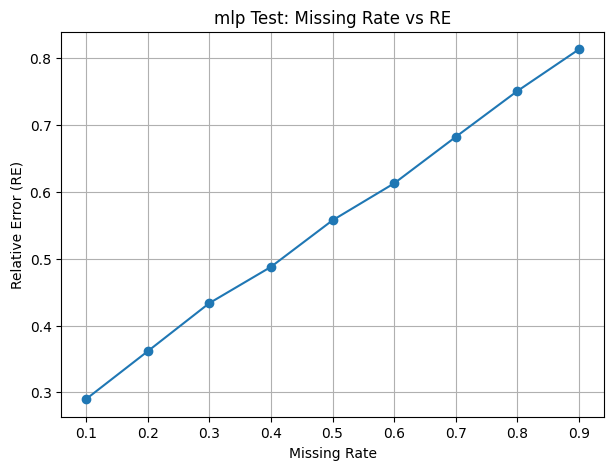

测试完成，结果图已保存至: f:\admm_net\result\mlp_test_RE_curve.png
[admm_net TEST] missing_rate = 0.10, RE = 0.305630
[admm_net TEST] missing_rate = 0.20, RE = 0.440001
[admm_net TEST] missing_rate = 0.30, RE = 0.541493
[admm_net TEST] missing_rate = 0.40, RE = 0.613787
[admm_net TEST] missing_rate = 0.50, RE = 0.692496
[admm_net TEST] missing_rate = 0.60, RE = 0.757801
[admm_net TEST] missing_rate = 0.70, RE = 0.824637
[admm_net TEST] missing_rate = 0.80, RE = 0.885967
[admm_net TEST] missing_rate = 0.90, RE = 0.936086


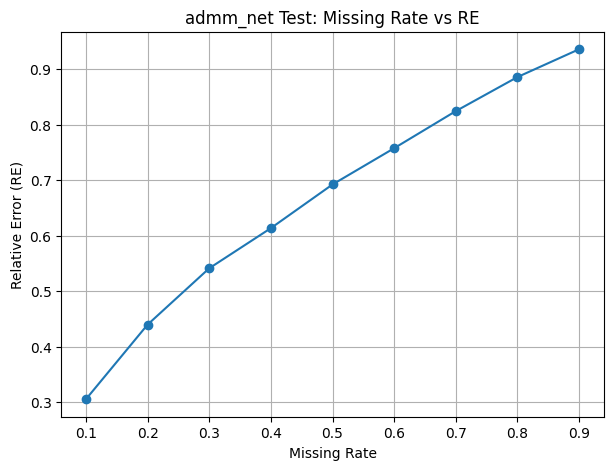

测试完成，结果图已保存至: f:\admm_net\result\admm_net_test_RE_curve.png


(array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
 [0.3056296110153198,
  0.4400007426738739,
  0.5414929389953613,
  0.6137873530387878,
  0.6924960017204285,
  0.7578014135360718,
  0.824637234210968,
  0.8859668374061584,
  0.9360858201980591])

In [151]:
script_dir = os.getcwd()
project_dir = os.path.dirname(script_dir)
result_img_dir = os.path.join(project_dir, "result")
setup_seed(24)
test_admm_net(device, mlp, result_img_dir, batch_size = 1024, model_name = "mlp")
setup_seed(24)
test_admm_net(device, admm_net, result_img_dir, batch_size = 1024, model_name = "admm_net")

In [132]:
@torch.no_grad()
def test_svd(device, result_img_dir, batch_size = 1024, rank_k = 4):
    os.makedirs(result_img_dir, exist_ok = True)

    missing_rates = np.arange(0.1, 1.0, 0.1)
    re_list = []

    # 生成 ground truth
    state, _ = generate_state_and_unexpected_event_probability(batch_size, device)
    X_gt = state.view(batch_size, 1, 1, -1)   # [B,1,1,F]
    X_gt2 = X_gt.squeeze(1).squeeze(1)       # [B,F] 用于 SVD 重构

    for missing_rate in missing_rates:
        mask = generate_mask(X_gt, missing_rate).to(device)

        # Z0 = mask 掉的数据
        Z0 = X_gt * mask
        Z0_mat = Z0.squeeze(1).squeeze(1)  # [B,F]

        U, S, Vh = torch.linalg.svd(Z0_mat, full_matrices=False)

        Uk = U[:, :rank_k]
        Sk = S[:rank_k]
        Vhk = Vh[:rank_k, :]

        X_pred2 = Uk @ torch.diag(Sk) @ Vhk  # shape [B, F]

        X_pred = X_pred2.view(batch_size, 1, 1, -1)

        # 计算 RE
        re = calc_re(X_gt, X_pred)
        re_list.append(re)

        print(f"[SVD TEST] missing_rate = {missing_rate:.2f}, RE = {re:.6f}")

    plt.figure(figsize=(7, 5))
    plt.plot(missing_rates, re_list, marker='o', label=f"SVD rank={rank_k}")
    plt.xlabel("Missing Rate")
    plt.ylabel("Relative Error (RE)")
    plt.title("SVD Test: Missing Rate vs RE")
    plt.grid(True)
    plt.legend()

    save_path = os.path.join(result_img_dir, "svd_test_RE_curve.png")
    plt.savefig(save_path, dpi=200)
    plt.show()
    plt.close()

    print(f"SVD 测试完成，结果图保存在: {save_path}")
    return missing_rates, re_list


[SVD TEST] missing_rate = 0.10, RE = 0.313476
[SVD TEST] missing_rate = 0.20, RE = 0.447621
[SVD TEST] missing_rate = 0.30, RE = 0.548929
[SVD TEST] missing_rate = 0.40, RE = 0.619583
[SVD TEST] missing_rate = 0.50, RE = 0.697387
[SVD TEST] missing_rate = 0.60, RE = 0.764393
[SVD TEST] missing_rate = 0.70, RE = 0.832495
[SVD TEST] missing_rate = 0.80, RE = 0.896655
[SVD TEST] missing_rate = 0.90, RE = 0.949844


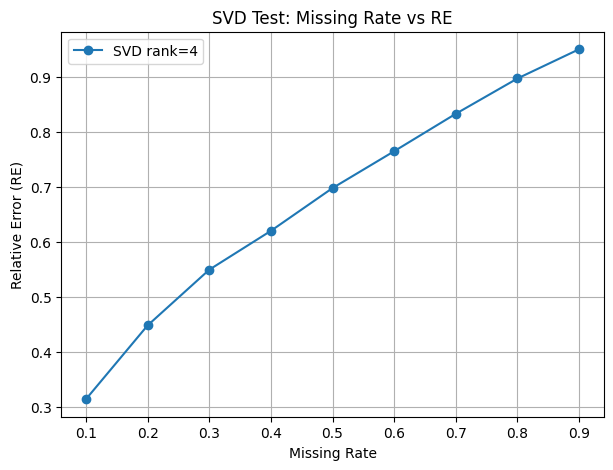

SVD 测试完成，结果图保存在: f:\admm_net\result\svd_test_RE_curve.png


(array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
 [0.3134758174419403,
  0.44762086868286133,
  0.5489294528961182,
  0.6195825338363647,
  0.6973869204521179,
  0.7643928527832031,
  0.8324949145317078,
  0.8966546654701233,
  0.9498440623283386])

In [139]:
setup_seed(24)
test_svd(device, result_img_dir, batch_size = 1024)

# DDQN

雷达模式(radar mode)
$$
a_{k}^{r} \\
k \in \{ 1, 2 \} \\
\text{short-range detection mode}: a_{1}^{r} \\
\text{long-range detection mode}: a_{2}^{r} \\

$$

通信模式(communication mode)
$$
a_{l}^{d}\\
d \in \{ \text{CAM}, \text{DENM} \} \\
l \in \{ 1, 2, 3, 4 \} \\
$$

$$
\begin{align*}

\text{Q-VALUE} &= Q(s, a; \theta) \\

a &= \operatorname*{argmax}_{a_j \in \mathcal{A}} Q(s,a_j;\theta) \\

\end{align*}
$$


In [33]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim = 2 + 8, hidden_dims = [128, 128]):
        super().__init__()
        layers = []
        in_features = state_dim
        for h_features in hidden_dims:
            layers.append(nn.Linear(in_features, h_features))
            layers.append(nn.ReLU())
            in_features = h_features

        layers.append(nn.Linear(in_features, action_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, state):
        return self.network(state)

In [34]:
def save_q_net(model, path):
    torch.save(model.state_dict(), path)
    print(f"已保存 Q-Network 模型至: {path}")

def load_q_net(config, path):
    state_dim = config["state_dim"]
    action_dim = config["action_dim"]
    hidden_dims = config["hidden_dims"]

    model = QNetwork(state_dim, action_dim, hidden_dims)
    state_dict = torch.load(path, map_location = torch.device("cpu"))
    model.load_state_dict(state_dict)

    print(f"已加载 Q-Network 模型自: {path}")

    return model

In [35]:
def q_vals_for_states(network, states):
    return network(states)

def q_vals_for_actions(q_vals, actions):
    if actions.dim() == 1:
        actions = actions.unsqueeze(1)

    actions = actions.long()
    return q_vals.gather(1, actions)

@torch.no_grad()
def actions_for_q_vals(q_vals):
    return q_vals.argmax(dim = 1, keepdim=True).long()

## State Transition Function

### Based on the canonical definition of Markov decision processes:
$$
\begin{align*}
\mathcal{T} &= P(s' | s, a) \\
\end{align*}
$$

### Paper:
$$
\begin{align*}
\mathcal{T} &= P(s' | p_{u}, s, n, a) \\
\end{align*}
$$

|   idx   |      action       |
|---------|-------------------|
|    0    | Radar short-range |
|    1    | Radar long-range  |
|    2    | CAM, l = 1        |
|    3    | CAM, l = 2        |
|    4    | CAM, l = 3        |
|    5    | CAM, l = 4        |
|    6    | DENM, l = 1       |
|    7    | DENM, l = 2       |
|    8    | DENM, l = 3       |
|    9    | DENM, l = 4       |

In [36]:
def transition(state, action):
    w  = state[:, 0]
    r  = state[:, 1]
    n  = state[:, 2]
    v  = state[:, 3]
    m_ack = state[:, 4]
    q  = state[:, 6]
    m  = state[:, 7]

    w_next = w
    r_next = r
    n_next = n
    v_next = v
    q_next = q
    m_next = m

    d_next = 11.0 - r_next

    SINR1 = generate_SINR(w_next, d_next)
    SINR2 = generate_SINR(w_next, d_next)

    c_next_1 = generate_channel_condition(SINR1)
    c_next_2 = generate_channel_condition(SINR2)

    action = action.squeeze(-1)

    is_radar = action < 2
    is_comm = ~is_radar

    # 动作 2~9 → comm_index = 0 ~ 7
    comm_index = (action - 2).clamp(min = 0)
    l_action_from_action = (comm_index % 4) + 1   # 1~4

    # 雷达动作没有通信，l_action 无意义，只给占位值
    l_action = torch.zeros_like(action)
    l_action[is_comm] = l_action_from_action[is_comm]


    m_ack_next = m_ack.clone()
    if is_comm.any():
        l_optimal_next = generate_communication_rate(c_next_2)

        l_action_tensor = l_action.unsqueeze(1)
        l_optimal_tensor = l_optimal_next.unsqueeze(1)

        ack_new = generate_ack_message(l_action_tensor, l_optimal_tensor).squeeze(1)

        m_ack_next[is_comm] = ack_new[is_comm].float()

    state_next = torch.stack(
        [
            w_next,
            r_next,
            n_next,
            v_next,
            m_ack_next,
            c_next_1,
            q_next,
            m_next,
        ], dim = 1
    )

    return state_next

## Reward

$$
r_{com}(t) = 
\begin{cases}

\alpha_{1}l & a = a_{l}^{d}, m = 1, X_{t} = 0 \\

-\alpha_{2}l & a = a_{l}^{d}, X_{t} = 1 \\

0 & a = a_{k}^{r} \\

\end{cases}
$$


In [37]:
def com_reward(alpha1, alpha2, l, is_comm_action, is_cam_message, is_accident):
    is_comm_action = is_comm_action.float()
    is_cam_message = is_cam_message.float()
    is_accident    = is_accident.float()

    reward_cam_normal = alpha1 * l * is_comm_action * is_cam_message * (1 - is_accident)
    reward_comm_accident = -alpha2 * l * is_comm_action * is_accident

    return reward_cam_normal + reward_comm_accident

$$
r_{rad}(t) = 
\begin{cases}

-\beta_{1}(1 - p_{u}(t)) & a = a_{k}^{r}, X_{t} = 0 \\

\beta_{2}(1 - p_{k}(t)) & a = a_{k}^{r}, X_{t} = 1 \\

\end{cases}
$$


In [38]:
def rad_reward(beta1, p_u, beta2, p_k, is_radar_action, is_accident):
    is_radar_action = is_radar_action.float()
    is_accident = is_accident.float()

    reward_no_accident = -beta1 * (1.0 - p_u) * is_radar_action * (1 - is_accident)
    reward_accident = beta2 * (1.0 - p_k) * is_radar_action * is_accident

    return reward_no_accident + reward_accident

$$
r_{age}(t) =
\begin{cases}

q_{\max} - \delta_{i} & a = a_{l}^{\text{DENM}}, \\

0 & a \neq a_{l}^{\text{DENM}} \\

\end{cases}
$$


In [39]:
def age_reward(q_max, delta_i, is_denm_action):
    is_denm_action = is_denm_action.float()
    return (q_max - delta_i) * is_denm_action

$$
\begin{align*}
R(t) &= \alpha r_{com}(t) + \beta r_{rad}(t) + \lambda r_{age}(t), \quad \alpha + \beta + \lambda = 1
\end{align*}
$$

In [40]:
def reward(alpha, r_com, beta, r_rad, param_lambda, r_age):
    return alpha * r_com + beta * r_rad + param_lambda * r_age 

$$
\begin{align*}
y &= r + \gamma (1 - done)\, Q'(s', a; \theta') \\
\end{align*}
$$

In [41]:
@torch.no_grad()
def generate_target(rewards, have_no_next_action, target_q_vals, gamma):
    return rewards + gamma * (1 - have_no_next_action) * target_q_vals

$$
\begin{align*}
\mathcal{L}(\theta) &= \frac{1}{2}\left( Q(s, a; \theta) - y \right)^{2}
\end{align*}
$$

In [42]:
def calc_ddqn_loss(online_q_vals, targets):
    return (0.5 * (online_q_vals - targets).pow(2)).mean()

In [43]:
class DDQNUpdater:
    def __init__(self, online_q_network, target_q_network, optimizer):
        self.online_q_network = online_q_network
        self.target_q_network = target_q_network
        self.optimizer = optimizer

    def update_online_q_net(self, loss):
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target_q_net(self):
        self.target_q_network.load_state_dict(
            self.online_q_network.state_dict()
        )

In [44]:
from collections import deque

In [45]:
class ReplayDeque:
    def __init__(self, maxlen):
        self.deque = deque(maxlen=maxlen)

    def append(self, state, action, next_state, reward, has_no_next_action):
        # state: numpy array shape (1,8)
        # next_state: numpy array shape (1,8)
        self.deque.append(
            (
                np.array(state, dtype=np.float32, copy=False),
                int(action),
                np.array(next_state, dtype=np.float32, copy=False),
                float(reward),
                float(has_no_next_action)
            )
        )

    def sample(self, batch_size):
        batch = random.sample(self.deque, batch_size)
        states, actions, next_states, rewards, dones = zip(*batch)

        # 保证整齐
        states      = np.concatenate(states, axis=0)
        next_states = np.concatenate(next_states, axis=0)
        actions     = np.array(actions, dtype=np.int64).reshape(-1, 1)
        rewards     = np.array(rewards, dtype=np.float32).reshape(-1, 1)
        dones       = np.array(dones, dtype=np.float32).reshape(-1, 1)

        return states, actions, next_states, rewards, dones

    def __len__(self):
        return len(self.deque)

In [46]:
class DDQNTrainer:
    def __init__(self, online_q_network, target_q_network, updater,
                 replay_buffer, gamma, batch_size, device):
        self.online_q_network = online_q_network
        self.target_q_network = target_q_network
        self.updater = updater
        self.replay_buffer = replay_buffer
        self.gamma = gamma
        self.batch_size = batch_size
        self.device = device

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return None

        states, actions, next_states, rewards, dones = self.replay_buffer.sample(self.batch_size)

        # tensor 转换
        states      = torch.tensor(states, dtype=torch.float32, device=self.device)
        actions     = torch.tensor(actions, dtype=torch.long, device=self.device)
        next_states = torch.tensor(next_states, dtype=torch.float32, device=self.device)
        rewards     = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        dones       = torch.tensor(dones, dtype=torch.float32, device=self.device)

        # 强制动作合法，避免 gather 崩溃
        A = self.online_q_network.network[-1].out_features
        actions = torch.clamp(actions, 0, A - 1)

        # Q(s, a)
        q_vals = q_vals_for_states(self.online_q_network, states)
        q_sa   = q_vals_for_actions(q_vals, actions)

        # Double DQN
        next_q_online = q_vals_for_states(self.online_q_network, next_states)
        next_actions  = actions_for_q_vals(next_q_online)

        next_q_target = q_vals_for_states(self.target_q_network, next_states)
        next_q_sa     = q_vals_for_actions(next_q_target, next_actions)

        # target
        targets = rewards + self.gamma * (1.0 - dones) * next_q_sa

        # loss
        loss = calc_ddqn_loss(q_sa, targets)

        # optimize
        self.updater.update_online_q_net(loss)

        return loss.item()


# 训练

In [166]:
def generate_states_with_ack_ratio(
    batch_size,
    device,
    target_ack_ratio=0.7,
    pool_factor=4,      # 每次先生成 pool_factor * batch_size 个样本当“池子”
    max_tries=10
):
    """
    返回 shape = [batch_size, 8] 的 states 和 [batch_size] 的 p_us，
    并尽量保证其中 m_ack == 1 的比例 >= target_ack_ratio。
    """
    needed_ack = int(batch_size * target_ack_ratio)

    for _ in range(max_tries):
        pool_size = batch_size * pool_factor

        # 先生成一大池样本
        states_pool, p_us_pool = generate_state_and_unexpected_event_probability(pool_size, device)
        m_ack_pool = states_pool[:, 4]

        # 找到 ACK=1 和 其他 的索引
        ack_idx   = (m_ack_pool == 1).nonzero(as_tuple=True)[0]
        other_idx = (m_ack_pool != 1).nonzero(as_tuple=True)[0]

        # 池子里 ACK=1 的样本数量不够，就再来一轮
        if ack_idx.numel() < needed_ack:
            continue

        # 先取需要数量的 ACK=1 样本
        chosen_ack_idx = ack_idx[:needed_ack]

        # 剩下的位置用“其他样本”填满
        remaining = batch_size - needed_ack
        if remaining > 0:
            if other_idx.numel() < remaining:
                # 其他样本不够，多生成几次也行，这里简单跳过重试
                continue
            chosen_other_idx = other_idx[:remaining]
            final_idx = torch.cat([chosen_ack_idx, chosen_other_idx], dim=0)
        else:
            final_idx = chosen_ack_idx

        # 按最终索引取子集
        states = states_pool[final_idx].to(device)
        p_us   = p_us_pool[final_idx].to(device)
        return states, p_us

    # 如果 max_tries 次都没成功，就退回原始分布（保证不会死循环）
    states, p_us = generate_state_and_unexpected_event_probability(batch_size, device)
    return states.to(device), p_us.to(device)


In [258]:
class RewardMixer(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha1 = nn.Parameter(torch.tensor(0.5))
        self.alpha2 = nn.Parameter(torch.tensor(0.5))
        self.beta1  = nn.Parameter(torch.tensor(0.5))
        self.beta2  = nn.Parameter(torch.tensor(0.5))

        self.alpha  = nn.Parameter(torch.tensor(0.34))
        self.beta   = nn.Parameter(torch.tensor(0.33))
        self.lam    = nn.Parameter(torch.tensor(0.33))

    def forward(self):
        return {
            "alpha1": self.alpha1,
            "alpha2": self.alpha2,
            "beta1":  self.beta1,
            "beta2":  self.beta2,
            "alpha":  self.alpha,
            "beta":   self.beta,
            "lambda": self.lam,
        }

In [ ]:
def train_ddqn(
    device,
    model,
    trainer,
    mixer,
    replay_buffer,
    start_epoch,
    end_epoch,
    save_model_per_n_epoch,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=20000,
    batch_size_per_episode=2000
):

    # Mixer 的优化器：仅更新奖励参数
    mixer_optimizer = torch.optim.Adam(mixer.parameters(), lr=1e-4)

    def get_epsilon(step):
        return epsilon_end + (epsilon_start - epsilon_end) * np.exp(-step / epsilon_decay)

    global_step = 0
    action_dim = model.network[-1].out_features

    episode_rewards = []
    episode_missed = []
    episode_throughput = []

    for episode in range(start_epoch, end_epoch + 1):

        # 一次性生成 batch_size_per_episode 个独立 state
        states, p_us = generate_state_and_unexpected_event_probability(
            batch_size_per_episode, device
        )
        states = states.to(device)  # [B, 8]
        p_us   = p_us.to(device)    # [B]

        ep_reward_scalar   = 0.0
        ep_missed          = 0
        ep_throughput      = 0.0

        # 存储本 episode 所有 reward tensor（用于 meta-loss）
        step_reward_tensors = []

        for i in range(batch_size_per_episode):

            global_step += 1
            epsilon = get_epsilon(global_step)

            s   = states[i:i+1]    # [1, 8]
            p_u = p_us[i:i+1]      # [1]

            # ε-greedy
            if random.random() < epsilon:
                action = torch.randint(0, action_dim, (1, 1), device=device)
            else:
                q_vals = model(s)
                action = q_vals.argmax(dim=1, keepdim=True)

            a = int(action.item())

            # 事故采样
            accident = float(torch.rand(1).item() < p_u.item())
            accident_tensor = torch.tensor([accident], dtype=torch.float32, device=device)

            # 状态值解析
            m_val = int(s[0, 7].item())  # 0,1,2,3

            has_cam_msg  = (m_val == 1) or (m_val == 3)
            has_denm_msg = (m_val == 2) or (m_val == 3)

            is_radar_mode = (a < 2)
            is_cam_mode   = (2 <= a <= 5)
            is_denm_mode  = (6 <= a <= 9)

            valid_cam_tx  = has_cam_msg  and is_cam_mode
            valid_denm_tx = has_denm_msg and is_denm_mode
            valid_comm    = valid_cam_tx or valid_denm_tx

            if is_cam_mode or is_denm_mode:
                l = (a - 2) % 4 + 1
            else:
                l = 0
            l_tensor = torch.tensor([l], dtype=torch.float32, device=device)

            # 状态转移
            next_state = transition(s, action).to(device)

            m_ack_next = next_state[:, 4]

            if valid_comm and int(m_ack_next.item()) == 1:
                ep_throughput += float(l)

            if accident and (not is_radar_mode):
                ep_missed += 1

            # 从 mixer 取奖励系数
            coeffs = mixer()

            # 通信奖励
            r_com = com_reward(
                alpha1 = coeffs["alpha1"],
                alpha2 = coeffs["alpha2"],
                l = l_tensor,
                is_comm_action = torch.tensor([float(valid_comm)], device=device),
                is_cam_message = torch.tensor([float(valid_cam_tx)], device=device),
                is_accident = accident_tensor
            )

            # 雷达奖励
            p_k_table = {0: 0.10, 1: 0.25}
            p_k_value = p_k_table[a] if is_radar_mode else 0.0
            p_k_tensor = torch.tensor([p_k_value], dtype=torch.float32, device=device)

            r_rad = rad_reward(
                beta1 = coeffs["beta1"],
                p_u   = p_u,
                beta2 = coeffs["beta2"],
                p_k   = p_k_tensor,
                is_radar_action = torch.tensor([float(is_radar_mode)], device=device),
                is_accident     = accident_tensor
            )

            # DENM 年龄奖励
            r_age = age_reward(
                q_max = 4,
                delta_i = s[0, 6],
                is_denm_action = torch.tensor([float(valid_denm_tx)], device=device)
            )

            # 总奖励
            total_reward = reward(
                alpha        = coeffs["alpha"],
                r_com        = r_com,
                beta         = coeffs["beta"],
                r_rad        = r_rad,
                param_lambda = coeffs["lambda"],
                r_age        = r_age
            )

            # 存储 reward（tensor）用于 meta-loss
            step_reward_tensors.append(total_reward)

            # 标量累计 (只是日志，不用于梯度)
            ep_reward_scalar += float(total_reward.item())

            # 存入 replay buffer
            replay_buffer.append(
                s.cpu().numpy(),
                a,
                next_state.cpu().numpy(),
                float(total_reward.item()),
                0.0
            )

            trainer.train_step()

        #  更新 target Q-network
        trainer.updater.update_target_q_net()

        #  episode 结束：对 mixer 进行一次 meta-loss 更新
        if len(step_reward_tensors) > 0:
            # maximize cumulative reward → minimize negative reward
            episode_reward_tensor = torch.stack(step_reward_tensors).mean()
            meta_loss = -episode_reward_tensor

            mixer_optimizer.zero_grad()
            meta_loss.backward()
            mixer_optimizer.step()

        episode_rewards.append(ep_reward_scalar)
        episode_missed.append(ep_missed)
        episode_throughput.append(ep_throughput)

        print(f"[Episode {episode}] R={ep_reward_scalar:.1f}, Miss={ep_missed}, Th={ep_throughput:.1f}")

        if episode % save_model_per_n_epoch == 0:
            save_q_net(model, f"ddqn_ep_{episode}.pth")

    np.save("episode_rewards.npy", episode_rewards)
    np.save("episode_missed.npy", episode_missed)
    np.save("episode_throughput.npy", episode_throughput)


In [264]:
state_dim = 8
action_dim = 10
hidden_dims = [128, 128]

online_q_net = QNetwork(state_dim, action_dim, hidden_dims).to(device)
target_q_net = QNetwork(state_dim, action_dim, hidden_dims).to(device)

target_q_net.load_state_dict(online_q_net.state_dict())

reward_mixer = RewardMixer().to(device)
optimizer = torch.optim.Adam(list(online_q_net.parameters()), lr=1e-3)


updater = DDQNUpdater(
    online_q_network=online_q_net,
    target_q_network=target_q_net,
    optimizer=optimizer
)

replay_buffer = ReplayDeque(maxlen = 50000)

trainer = DDQNTrainer(
    online_q_network = online_q_net,
    target_q_network = target_q_net,
    updater = updater,
    replay_buffer = replay_buffer,
    gamma = 0.99,
    batch_size = 128,
    device = device
)

train_ddqn(
    device = device,
    model = online_q_net,
    trainer = trainer,
    mixer = reward_mixer,
    replay_buffer = replay_buffer,
    start_epoch = 1,
    end_epoch = 100,
    save_model_per_n_epoch=5
)

[Episode 1] R=336.3, Miss=801, Th=874.0
[Episode 2] R=358.4, Miss=776, Th=870.0
[Episode 3] R=413.8, Miss=762, Th=874.0
[Episode 4] R=439.0, Miss=821, Th=890.0
[Episode 5] R=509.9, Miss=793, Th=980.0
已保存 Q-Network 模型至: ddqn_ep_5.pth
[Episode 6] R=499.1, Miss=794, Th=927.0
[Episode 7] R=552.3, Miss=799, Th=1051.0
[Episode 8] R=557.3, Miss=767, Th=1032.0
[Episode 9] R=584.3, Miss=816, Th=1017.0
[Episode 10] R=625.1, Miss=823, Th=1059.0
已保存 Q-Network 模型至: ddqn_ep_10.pth
[Episode 11] R=652.1, Miss=816, Th=1118.0
[Episode 12] R=683.7, Miss=764, Th=1011.0
[Episode 13] R=713.2, Miss=779, Th=1008.0
[Episode 14] R=695.0, Miss=802, Th=1022.0
[Episode 15] R=720.2, Miss=796, Th=1076.0
已保存 Q-Network 模型至: ddqn_ep_15.pth
[Episode 16] R=745.7, Miss=802, Th=1062.0
[Episode 17] R=711.4, Miss=801, Th=1002.0
[Episode 18] R=713.0, Miss=812, Th=994.0
[Episode 19] R=769.2, Miss=814, Th=1051.0
[Episode 20] R=779.1, Miss=803, Th=967.0
已保存 Q-Network 模型至: ddqn_ep_20.pth
[Episode 21] R=751.8, Miss=829, Th=1087.0


In [266]:
reward_mixer()

{'alpha1': Parameter containing:
 tensor(0.5100, device='cuda:0', requires_grad=True),
 'alpha2': Parameter containing:
 tensor(0.4905, device='cuda:0', requires_grad=True),
 'beta1': Parameter containing:
 tensor(0.4902, device='cuda:0', requires_grad=True),
 'beta2': Parameter containing:
 tensor(0.5105, device='cuda:0', requires_grad=True),
 'alpha': Parameter containing:
 tensor(0.3318, device='cuda:0', requires_grad=True),
 'beta': Parameter containing:
 tensor(0.3409, device='cuda:0', requires_grad=True),
 'lambda': Parameter containing:
 tensor(0.3407, device='cuda:0', requires_grad=True)}

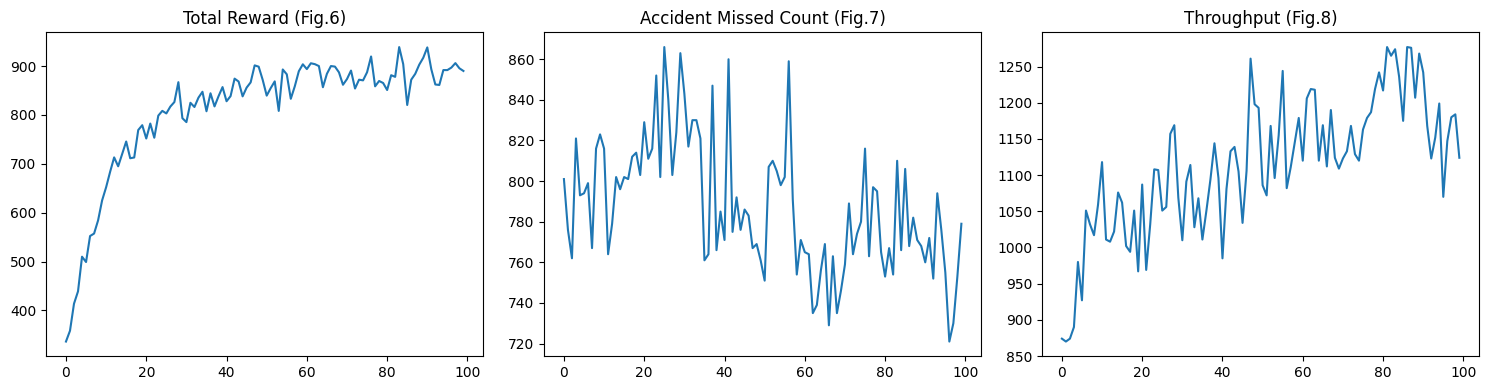

In [265]:
rewards = np.load("episode_rewards.npy")
missed = np.load("episode_missed.npy")
throughput = np.load("episode_throughput.npy")

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(rewards)
plt.title("Total Reward (Fig.6)")

plt.subplot(1,3,2)
plt.plot(missed)
plt.title("Accident Missed Count (Fig.7)")

plt.subplot(1,3,3)
plt.plot(throughput)
plt.title("Throughput (Fig.8)")

plt.tight_layout()

save_path = os.path.join(result_img_dir, "ddqn.png")    
plt.savefig(save_path, dpi=200)

plt.show()
plt.close()